# Asking questions about random vectors

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln


In [88]:
method = 'normal'
if method not in {'normal','uniform'}:
    raise ValueError('unknown method')

In [89]:



num_vecs = 1000

L2_means = []
L1_means = []
dims = np.arange(1,500)

for d in dims:
    if method == 'uniform':
        vecs = np.random.uniform(-.5,.5,(d,num_vecs))
    elif method == 'normal':
        vecs = np.random.normal(0,1,(d,num_vecs))
    mean_L2_norm = np.mean(np.linalg.norm(vecs, axis=0))
    mean_L1_norm = np.mean(np.linalg.norm(vecs,axis = 0,ord=1))
    L2_means.append(mean_L2_norm)
    L1_means.append(mean_L1_norm)




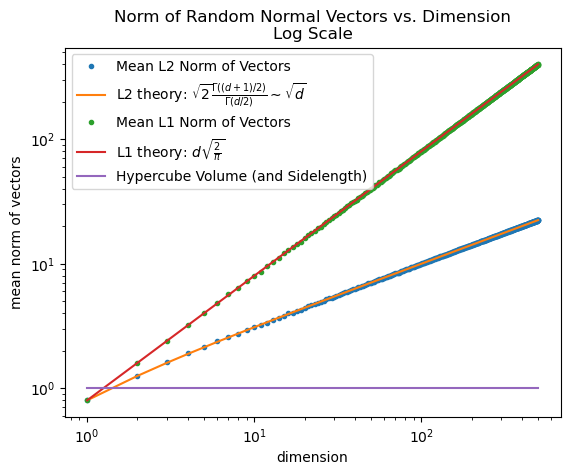

In [90]:
if method == 'uniform':
    L2_means = np.asarray(L2_means)
    L1_means = np.asarray(L1_means)

    L2_theory = np.sqrt(dims / 12)
    L1_theory = dims / 4

    plt.loglog(dims, L2_means, '.', label='Mean L2 Norm of Vectors')
    plt.loglog(dims, L2_theory, '-', label=r'L2 theory: $=\frac{1}{2\sqrt{3}}\sqrt{d}$')

    plt.loglog(dims, L1_means, '.', label='Mean L1 Norm of Vectors')
    plt.loglog(dims, L1_theory, '-', label=r'L1 theory: $\frac{d}{4}$')

    plt.xlabel('dimension')
    plt.ylabel('mean norm of vectors')
    plt.title('Norm of Random Vectors in a Hypercube vs. Dimension\nLog Scale')
    plt.loglog(dims, np.ones(dims.shape), label='Hypercube Volume (and Sidelength)')

    plt.legend()
    plt.show()


elif method == 'normal':

    L2_means = np.asarray(L2_means)
    L1_means = np.asarray(L1_means)

    L2_theory = np.sqrt(2) * np.exp(gammaln((dims + 1) / 2) - gammaln(dims / 2))
    L1_theory = dims * np.sqrt(2 / np.pi)

    plt.loglog(dims, L2_means, '.', label='Mean L2 Norm of Vectors')
    plt.loglog(
        dims,
        L2_theory,
        '-',
        label=r'L2 theory: $\sqrt{2}\frac{\Gamma((d+1)/2)}{\Gamma(d/2)} \sim \sqrt{d}$'
    )

    plt.loglog(dims, L1_means, '.', label='Mean L1 Norm of Vectors')
    plt.loglog(
        dims,
        L1_theory,
        '-',
        label=r'L1 theory: $d\sqrt{\frac{2}{\pi}}$'
    )

    plt.xlabel('dimension')
    plt.ylabel('mean norm of vectors')
    plt.title('Norm of Random Normal Vectors vs. Dimension\nLog Scale')

    plt.loglog(dims, np.ones(dims.shape), label='Hypercube Volume (and Sidelength)')


    plt.legend()
    plt.show()


In [91]:
# Calculate empirical distributions of pairwise angles between random vectors.

angle_num_vecs = 3_000
angle_dims = np.array([2, 3, 5, 10, 20, 50, 100, 200])
angle_distributions = {}
cosine_distributions = {}

for d in angle_dims:
    if method == 'uniform':
        vecs = np.random.uniform(-0.5, 0.5, (d, angle_num_vecs))
    elif method == 'normal':
        vecs = np.random.normal(0, 1, (d, angle_num_vecs))
    norms = np.linalg.norm(vecs, axis=0)
    nonzero = norms > 0
    unit_vecs = vecs[:, nonzero] / norms[nonzero]

    pairwise_cosines = unit_vecs.T @ unit_vecs
    i, j = np.triu_indices(pairwise_cosines.shape[0], k=1)
    pairwise_cosines = pairwise_cosines[i, j]
    pairwise_cosines = np.clip(pairwise_cosines, -1.0, 1.0)

    cosine_distributions[d] = pairwise_cosines
    angle_distributions[d] = np.arccos(pairwise_cosines)


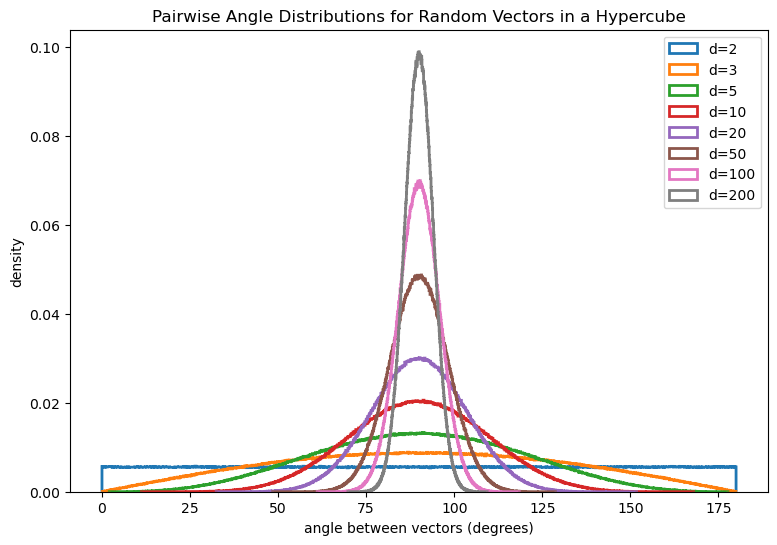

In [92]:
# Plot empirical angle distributions.

plt.figure(figsize=(9, 6))

for d in angle_dims:
    plt.hist(
        np.degrees(angle_distributions[d]),
        bins=600,
        density=True,
        histtype='step',
        linewidth=2,
        label=f'd={d}',
    )

plt.xlabel('angle between vectors (degrees)')
plt.ylabel('density')
plt.title('Pairwise Angle Distributions for Random Vectors in a Hypercube')
plt.legend()
plt.show()
